In [1]:
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve() / 'py_modules')) 
from spectral_lines import LINES, print_available_lines
from astronomical_instruments import INSTRUMENTS, print_available_instruments
from astronomical_objects import OBJECTS, print_available_objects

In [3]:
cfg = LINES["Halpha"]

plot_label = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element = cfg.element
ion = cfg.ion
transition_id = cfg.transition_id

print(plot_label)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

H$\alpha$
6562.79
6563
H
Ha
H_I-6563


In [4]:
nebula = OBJECTS["30Doradus"]

catalog_name = nebula.catalog_name
common_name  = nebula.common_name
object_type  = nebula.object_type
object_id    = nebula.object_id
dist = nebula.distance_pc
pc         = nebula.pc_per_arcsec

print(catalog_name)
print(common_name)
print(object_type)
print(object_id)
print(dist)
print(pc)

NGC 2070
30 Doradus
H II region
30Dor
50000
0.24240684055476797


In [5]:
inst_id = 'SAMFP'   
inst = 'SAMFP'
pix  = 0.18

In [6]:
bins = 0
name_id =  inst_id + '-' + object_id + '-' + ion + '-' + 'bin' + str(bins)
name_file = name_id
print(name_id)

SAMFP-30Dor-Ha-bin0


In [7]:
s0_        = 0.9    # proposed seeing
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

In [8]:
sb = fits.open('Halpha_moment0.fits' )[0].data.astype(float)
vv = fits.open('Halpha_moment1.fits' )[0].data.astype(float)
ss = fits.open('Halpha_moment2.fits' )[0].data.astype(float)

In [9]:
hdul_mask = fits.open('fits_ready/mask_cont.fits')
mask = hdul_mask['MASK'].data.astype(bool)

/var/folders/1s/7p4dmrfd0d7d8t0h6trn9dhw0000gr/T/ipykernel_53763/4042332810.py:15: RuntimeWarning: invalid value encountered in log10
  im = axx.imshow(np.log10(sb), **imshow_kwds2)


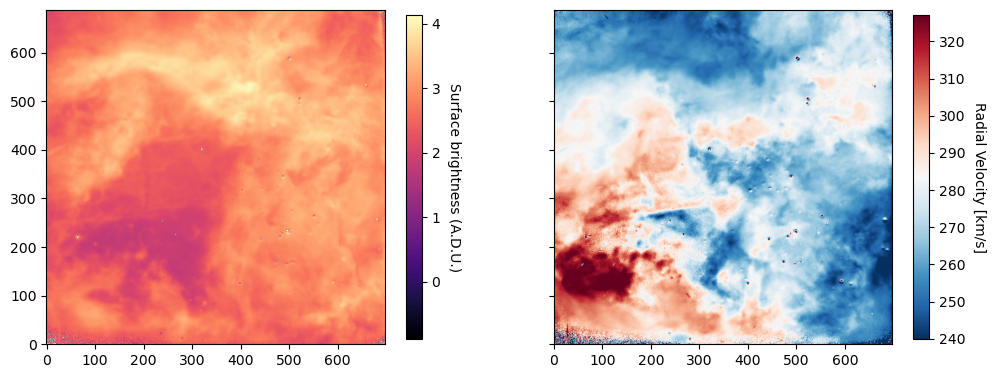

In [10]:
import matplotlib.pyplot as plt

fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

Continuum

In [11]:
vv = np.where(mask, vv, np.nan)     
sb = np.where(mask, sb, np.nan) 

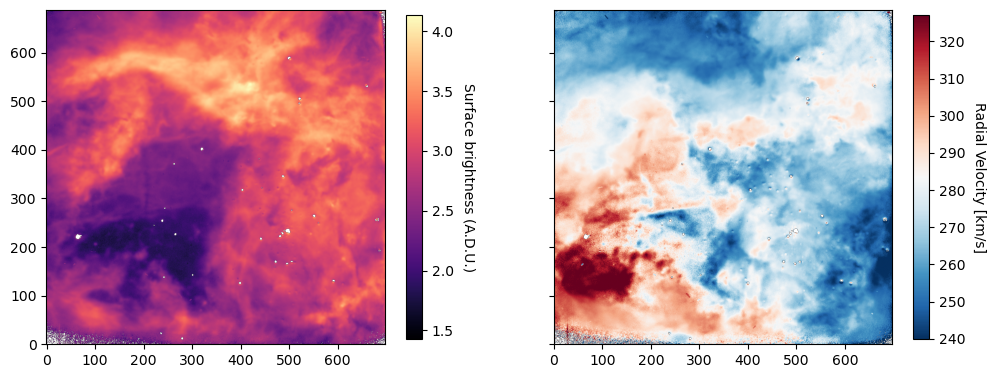

In [12]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [13]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb /= sb.max()

good = (~m) & (sb > 0.001)

In [14]:
vv_m = np.where(good, vv, np.nan)     
sb_m = np.where(good, sb, np.nan)
ss_m = np.where(good, ss, np.nan)

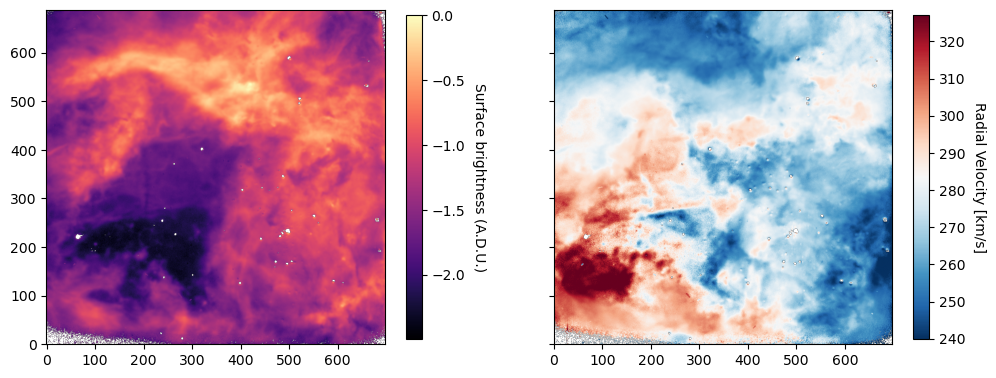

In [15]:
import matplotlib.pyplot as plt

fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb_m), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

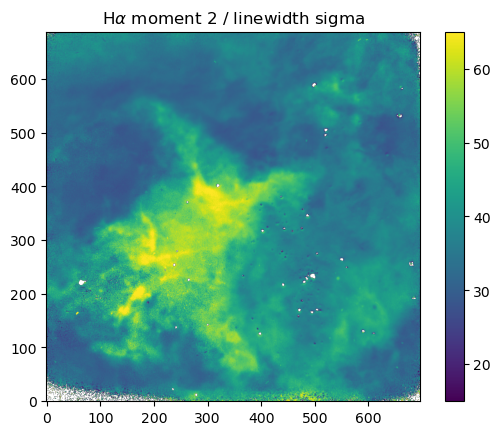

In [16]:
plt.imshow(ss_m,vmin = 15, vmax=65, origin="lower")
plt.colorbar()
plt.title(r"H$\alpha$ moment 2 / linewidth sigma")
plt.show()

Text(0.5, 1.0, 'Ha Flux')

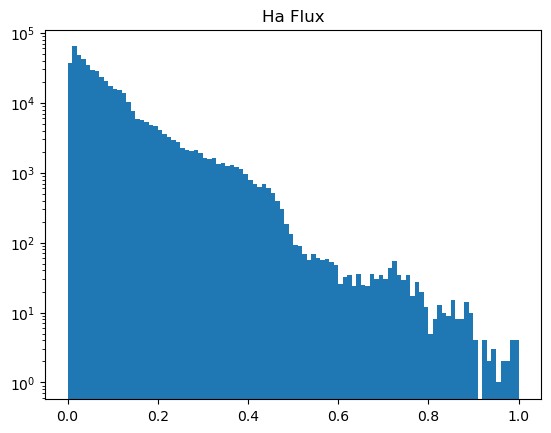

In [17]:
fig, ax = plt.subplots()
plt.hist(sb[np.isfinite(sb)] , bins=100)
ax.set_yscale("log")
ax.set_title('Ha Flux')

Text(0.5, 1.0, 'Ha velocity')

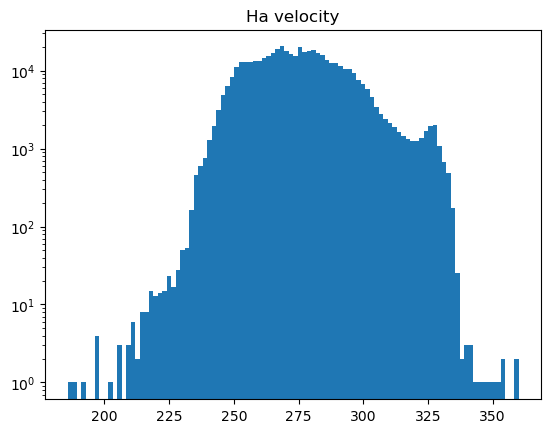

In [18]:
fig, ax = plt.subplots()
plt.hist(vv[np.isfinite(vv)& (np.abs(vv) < 1000)] , bins=100)
ax.set_yscale("log")
ax.set_title('Ha velocity')

Text(0.5, 1.0, 'Sigma velocity')

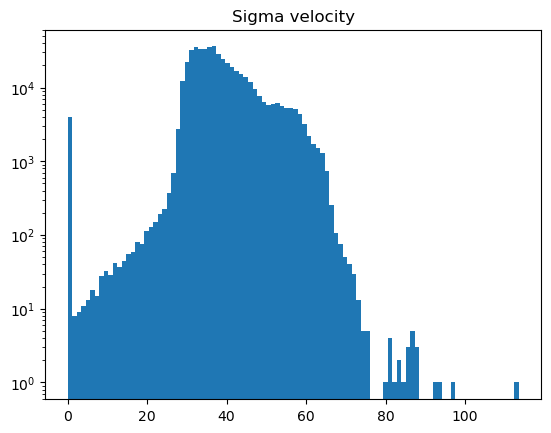

In [19]:
fig, ax = plt.subplots()
plt.hist(ss[np.isfinite(ss)& (np.abs(ss) < 500)] , bins=100)
ax.set_yscale("log")
ax.set_title('Sigma velocity')

In [20]:
mask_vv = (vv > 220) & (vv < 340)

In [21]:
vv_m = np.where(mask_vv, vv, np.nan)     
sb_m = np.where(mask_vv, sb, np.nan)
ss_m = np.where(mask_vv, ss, np.nan)

Text(0.5, 1.0, 'Ha velocity')

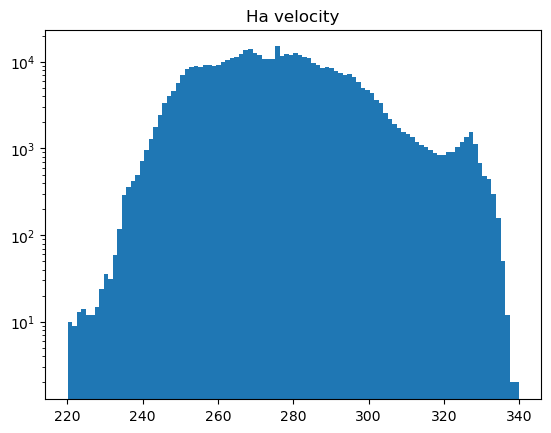

In [22]:
fig, ax = plt.subplots()
plt.hist(vv_m[np.isfinite(vv_m)& (np.abs(vv_m) < 1000)] , bins=100)
ax.set_yscale("log")
ax.set_title('Ha velocity')

/var/folders/1s/7p4dmrfd0d7d8t0h6trn9dhw0000gr/T/ipykernel_53763/1473187469.py:15: RuntimeWarning: divide by zero encountered in log10
  im = axx.imshow(np.log10(sb_m), **imshow_kwds2)


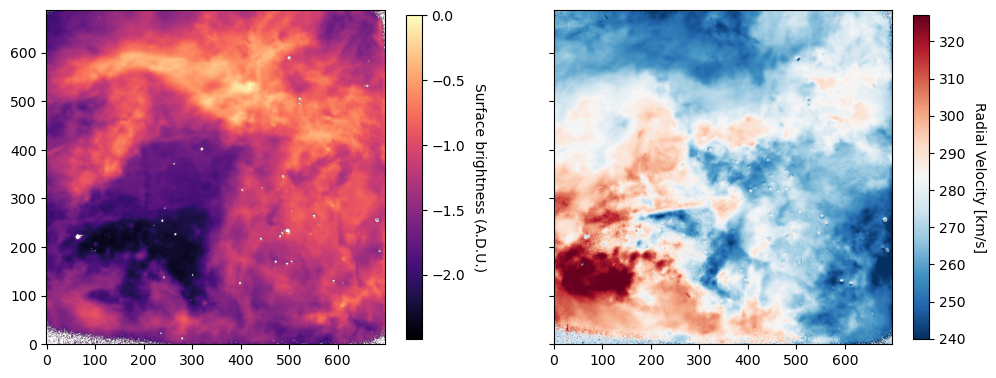

In [23]:
import matplotlib.pyplot as plt

fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m,vmin = 240, vmax=327,**imshow_kwds)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(sb_m), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

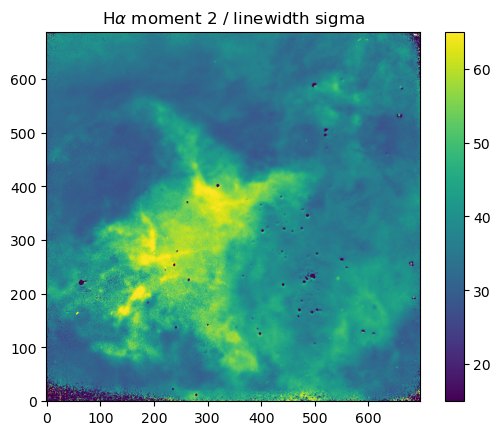

In [24]:
plt.imshow(ss_m,vmin = 15, vmax=65, origin="lower")
plt.colorbar()
plt.title(r"H$\alpha$ moment 2 / linewidth sigma")
plt.show()

In [25]:
sb_m1 = np.where(np.isnan(sb_m), 0, sb_m)     
vv_m1 = np.where(np.isnan(vv_m), np.nanmean(vv_m), vv_m)  
ss_m1 = np.where(np.isnan(ss_m), 0, vv_m)  

In [26]:
N = np.sqrt(vv_m1.shape[0] * vv_m1.shape[1]) * pix * pc
#N = np.sqrt(200 * 250) * pix * pc
N

np.float64(30.237325584080512)

In [27]:
sig = np.nanstd(vv_m1)
sig

np.float64(17.915777692672457)

In [28]:
mask = good & mask_vv & mask

In [29]:
primary = fits.PrimaryHDU()
primary.header["FILE"]       = (name_file, "Fits file name")
primary.header["NAME_ID"]    = (name_id, "pipeline identifier")
primary.header["REG"]        = (catalog_name, "Region catalog name")
primary.header["NAME_REG"]   = (common_name, "Region name")
primary.header["REG_ID"]     = (object_id, "Region identifier")
primary.header["TYPE_OBJ"]   = (object_type, "Type object")
primary.header["DIST"]       = (dist, "Distance in parsecs")
primary.header["INSTR"]      = (inst, "Instrument")
primary.header["LINE"]       = (plot_label, "Emission line name")
primary.header["LINE_ID"]    = (transition_id, "Emission line identifier")
primary.header["L_REST"]     = (rest_wavelength, "Emission line name")
primary.header["SIG"]        = (sig, "Standard deviation vel map")
primary.header["SIG2"]       = (sig**2, "Vel Variance map")
primary.header["S0"]         = (s0, "Atmospheric seeing")
primary.header["BOX_SIZE"]   = (N* (2**bins), "Observational box_size")
primary.header["PC"]         = (pc, "parsec convertion")
primary.header["PIX"]        = (pix* (2**bins), "Instrument pixel scale")
primary.header["BINSIZE"]    = (bins, "Spatial binning factor")
#hdr["noise"]     = (noise, "Instrumental noise")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")
primary.header["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")

In [30]:
hdu_m0 = fits.ImageHDU(data=sb_m1,  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m1,  name='MOM1')
hdu_m2 = fits.ImageHDU(data=ss_m1,  name='MOM2')
hdu_mask = fits.ImageHDU(data=mask.astype(np.uint8) ,  name='MASK')

In [31]:
hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_m2, hdu_mask])
hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

In [32]:
with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)

Filename: fits_ready/SAMFP-30Dor-Ha-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (697, 689)   float64   
  2  MOM1          1 ImageHDU         8   (697, 689)   float64   
  3  MOM2          1 ImageHDU         8   (697, 689)   float64   
  4  MASK          1 ImageHDU         8   (697, 689)   uint8   
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'SAMFP-30Dor-Ha-bin0' / Fits file name                                NAME_ID = 'SAMFP-30Dor-Ha-bin0' / pipeline identifier                           REG     = 'NGC 2070'           / Region catalog name                            NAME_REG= '30 Dorad